In [21]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# mpl.rc('font', family='serif', serif='cmr10', size=10)
mpl.rc('font', family='times new roman', size=12)
plt.rcParams['axes.unicode_minus'] = False

In [22]:
import pandas as pd
df0 = pd.read_csv('p_grid_results_price_20.csv',sep=',')
df0

,h,s,p_grid,omega,p_wt,p_el,p_comp,m_in,m_out,m_tank
0,1,1,643.359068,1036.9096,905.236668,1514.897745,33.697991,30358.55082,25000.000000,5358.550815
1,1,2,565.317462,1250.2617,1051.457358,1581.593227,35.181592,31695.12827,25000.000000,6695.128273
2,1,3,0.000000,96.7304,580.141465,567.517382,12.624084,11373.04833,9067.268934,2305.779391
3,2,1,359.126855,709.8295,786.486754,1120.684651,24.928958,22458.52041,25000.000000,2817.071225
4,2,2,0.000000,749.2752,933.735161,913.416753,20.318408,18304.87173,25000.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
499,167,2,340.994936,988.0428,934.260054,1247.504990,27.750000,25000.00000,25000.000000,0.000000
500,167,3,0.000000,0.0000,639.738270,625.817339,13.920931,12541.37948,5203.160702,7338.218774
501,168,1,252.025298,477.7642,1023.229692,1247.504990,27.750000,25000.00000,25000.000000,0.000000
502,168,2,333.580313,1062.7963,941.674678,1247.504990,27.750000,25000.00000,25000.000000,0.000000


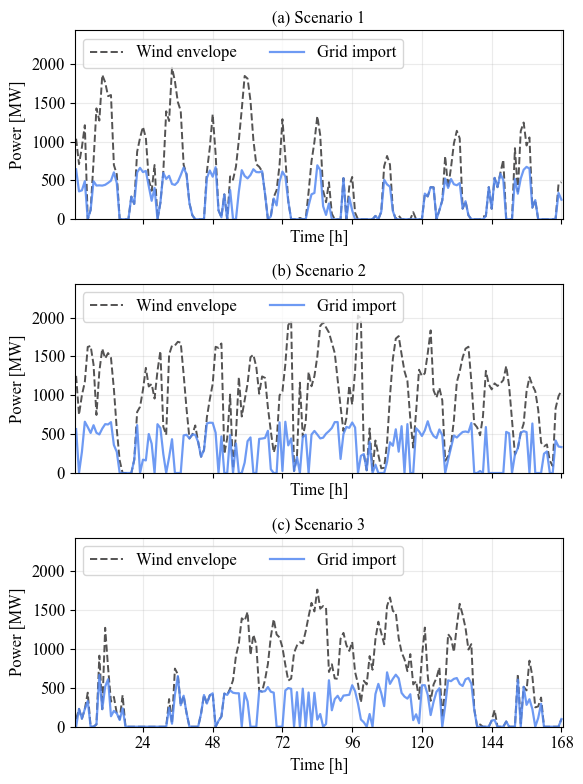

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure numeric
df0["h"] = pd.to_numeric(df0["h"], errors="raise")
df0["s"] = pd.to_numeric(df0["s"], errors="raise")
df0["p_grid"] = pd.to_numeric(df0["p_grid"], errors="raise")
df0["omega"] = pd.to_numeric(df0["omega"], errors="raise")

scenarios = sorted(df0["s"].unique())
if len(scenarios) != 3:
    print(f"Warning: expected 3 scenarios, found {len(scenarios)} -> {scenarios}")

# Common y-limits for fair comparison
ymax = np.nanmax([df0["p_grid"].max(), df0["omega"].max()])
ymin = 0.0

# X ticks every 24 h
xmin = df0["h"].min()
xmax = df0["h"].max()
xticks = np.arange(int(np.floor(xmin / 24)) * 24, int(np.ceil(xmax / 24)) * 24 + 1, 24)

fig, axes = plt.subplots(
    nrows=len(scenarios), ncols=1,
    figsize=(6, 8.0),
    sharex=True, sharey=True
)

if len(scenarios) == 1:
    axes = [axes]

for idx, (ax, s) in enumerate(zip(axes, scenarios)):
    d = df0[df0["s"] == s].sort_values("h")

    ax.plot(d["h"], d["omega"], linestyle="--", linewidth=1.4, label="Wind envelope", color="#363535", alpha = 0.85)
    ax.plot(d["h"], d["p_grid"], linestyle="-",  linewidth=1.6, label="Grid import", color="#5589F2", alpha = 0.85)


    ax.set_ylim(ymin, ymax*1.2)
    ax.set_xticks(xticks)
    ax.set_xlabel("Time [h]")
    ax.set_xlim(xmin - 0.5, xmax + 0.5)
    ax.set_ylabel("Power [MW]")
    ax.grid(True, axis="both", alpha=0.25)
    ax.legend(loc="upper left", fontsize=12, ncols=2)
    panel = chr(ord("a") + idx)
    ax.set_title(f"({panel}) Scenario {int(s)}", loc="center", fontsize=12)

axes[-1].set_xlabel("Time [h]")

plt.tight_layout()
plt.savefig("grid_power_comparison.pdf", bbox_inches="tight")
plt.show()


In [24]:
# Total grid power (sum of p_grid) per scenario
total_grid_power = df0.groupby("s")["p_grid"].sum()
total_grid_power

s
1    43827.829752
2    52753.748778
3    40419.541646
Name: p_grid, dtype: float64

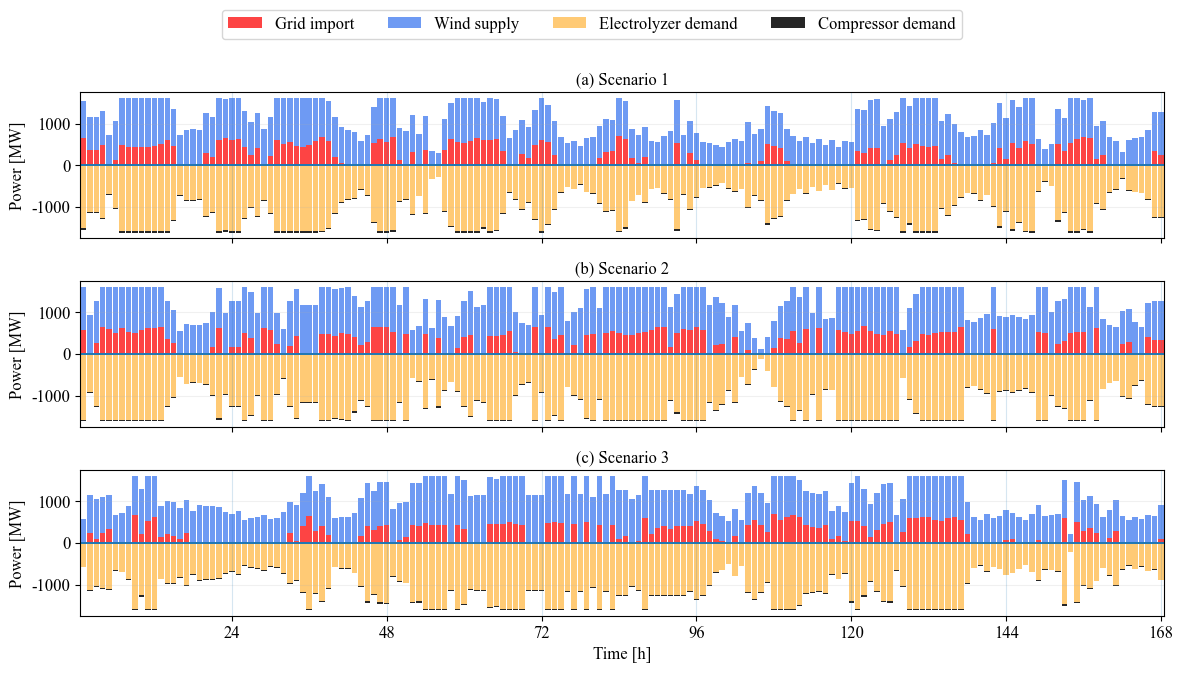

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- assumes df0 has columns: h, s, p_grid, p_wt, p_el, p_comp ---
scenarios = sorted(df0["s"].unique())

fig, axes = plt.subplots(
    nrows=len(scenarios), ncols=1,
    figsize=(12, 6.6),
    sharex=True, sharey=True
)

if len(scenarios) == 1:
    axes = [axes]

# Consistent styling
BAR_W = 0.85
ALPHA = 0.85
DAY = 24

for idx, (ax, s) in enumerate(zip(axes, scenarios)):
    d = df0[df0["s"] == s].sort_values("h").copy()

    h = d["h"].to_numpy()

    # Supply (positive)
    grid = d["p_grid"].to_numpy()
    wind = d["p_wt"].to_numpy()

    # Demand (plotted negative for readability)
    el_neg = -d["p_el"].to_numpy()
    comp_neg = -d["p_comp"].to_numpy()

    # ---- Positive stack: Grid + Wind ----
    ax.bar(h, grid, width=BAR_W, label="Grid import", alpha=ALPHA, color="#FD2323")
    ax.bar(h, wind, width=BAR_W, bottom=grid, label="Wind supply", alpha=ALPHA, color="#5589F2")

    # ---- Negative stack: Electrolyzer + Compressor ----
    ax.bar(h, el_neg, width=BAR_W, label="Electrolyzer demand", alpha=ALPHA, color="#FFC15D")
    ax.bar(h, comp_neg, width=BAR_W, bottom=el_neg, label="Compressor demand", alpha=ALPHA, color="#000000")

    # Emphasize the zero line
    ax.axhline(0, linewidth=1.4)

    # Day separators (every 24 h)
    hmin = int(np.floor(h.min()))
    hmax = int(np.ceil(h.max()))
    day_marks = np.arange((hmin // DAY + 1) * DAY, hmax + 1, DAY)
    for dm in day_marks:
        ax.axvline(dm, linewidth=0.8, alpha=0.18)

    # Cosmetics
    ax.set_ylabel("Power [MW]")
    ax.grid(True, axis="y", alpha=0.18)
    ax.grid(False, axis="x")
    panel = chr(ord("a") + idx)
    ax.set_title(f"({panel}) Scenario {int(s)}", fontsize=12)

# Shared legend (single)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.03)
)

# X ticks every 24 h
xmin = df0["h"].min()
xmax = df0["h"].max()
xticks = np.arange(int(np.floor(xmin / DAY)) * DAY, int(np.ceil(xmax / DAY)) * DAY + 1, DAY)
axes[-1].set_xticks(xticks)
axes[-1].set_xlabel("Time [h]")
axes[-1].set_xlim(xmin - 0.5, xmax + 0.5)

# Shared y-lims (keeps comparability)
pos_max = (df0["p_grid"] + df0["p_wt"]).max()
neg_min = -(df0["p_el"] + df0["p_comp"]).max()
ymax = np.ceil(pos_max / 250) * 250
ymin = -np.ceil(abs(neg_min) / 250) * 250
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("power_supply_demand_stack.pdf", bbox_inches="tight")
plt.show()


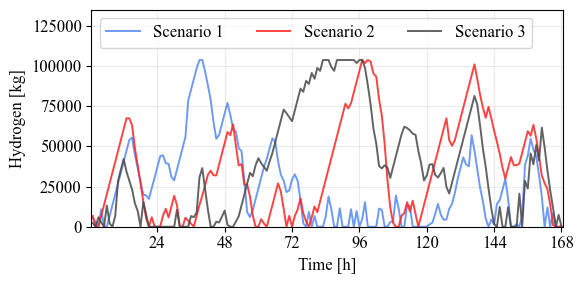

In [26]:
# Common y-limits for fair comparison
ymax = df0["m_tank"].max()
ymin = 0.0

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#5589F2",  # blue
    "Scenario 2": "#FD2323",  # orange
    "Scenario 3": "#494848",  # green
}

fig, ax = plt.subplots(figsize=(6, 3))

for s in scenarios:
    d = df0[df0["s"] == s].sort_values("h")
    label = f"Scenario {int(s)}"
    color = curve_colors.get(label, None)
    ax.plot(d["h"], d["m_tank"], linestyle="-", linewidth=1.4,
            label=label, color=color, alpha=0.85)

ax.set_xticks(xticks)
ax.set_xlabel("Time [h]")
ax.set_xlim(xmin - 0.5, xmax + 0.5)
ax.set_ylim(ymin, ymax * 1.3)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Hydrogen [kg]")
ax.grid(True, axis="both", alpha=0.25)
ax.legend(ncol=3, loc="upper left")

plt.tight_layout()
plt.savefig("hydrogen_tank_all_scenarios.pdf", bbox_inches="tight")
plt.show()


In [27]:
import pandas as pd
df1 = pd.read_csv('wind_profiles.csv',sep=',')
df1

,h,Scenario 1,Scenario 2,Scenario 3
0,1,0.858473,0.900416,0.912490
1,2,0.869290,0.801976,0.738599
2,3,0.960896,0.906306,0.660693
3,4,0.993691,0.961616,0.734159
4,5,0.785778,0.984375,0.813699
...,...,...,...,...
163,164,0.401486,0.717599,0.689430
164,165,0.506182,0.734029,0.572504
165,166,0.372308,0.878156,0.603768
166,167,0.480332,0.910871,0.582398


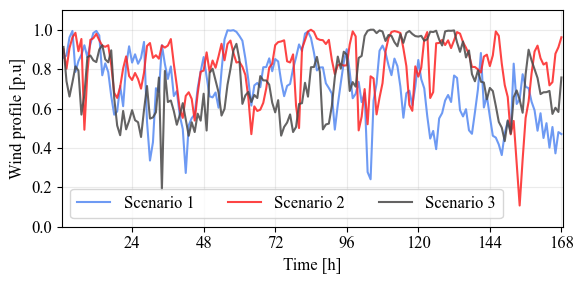

In [28]:
# Detect a likely time column (if present)
hour_candidates = [c for c in df1.columns if str(c).strip().lower() in ("h", "hour", "hours", "time")]
hour_col = hour_candidates[0] if hour_candidates else None

# Build x-axis from time column, otherwise use row index
x = pd.to_numeric(df1[hour_col], errors="coerce") if hour_col else pd.Series(range(len(df1)), index=df1.index)

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#5589F2",  # blue
    "Scenario 2": "#FD2323",  # orange
    "Scenario 3": "#494848",  # green
}

fig = plt.figure(figsize=(6, 3))
for c in df1.columns:
    if c == hour_col:
        continue
    y = pd.to_numeric(df1[c], errors="coerce")
    plt.plot(x, y, label=c, color=curve_colors.get(c, "#333333"), alpha=0.85)

plt.xlabel("Time [h]" if hour_col else "Index")
plt.ylabel("Wind profile [p.u]")
plt.xticks(xticks)
plt.xlabel("Time [h]")
plt.xlim(xmin - 0.5, xmax + 0.5)
plt.ylim(0, 1.1)
plt.legend(ncol=3, loc="lower left")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("wind_profiles.pdf", bbox_inches="tight")
plt.show()

In [29]:
import numpy as np
import pandas as pd

# -------------------------
# Load exported CSVs
# -------------------------
lines = pd.read_csv("trace_lines.csv")              # i,j
flows = pd.read_csv("trace_flows.csv")              # i,j,h,s,f_mw
wind  = pd.read_csv("trace_wind.csv")               # w,bus,zone,h,s,net_mw
therm = pd.read_csv("trace_thermal_bus.csv")        # i,h,s,pT_mw
plant = pd.read_csv("trace_plant.csv")              # k,h,s,yD,pplant_mw
pi_df = pd.read_csv("trace_pi.csv")                 # s,pi
pi_s = dict(zip(pi_df["s"].astype(int), pi_df["pi"].astype(float)))

# Bus set
buses = sorted(set(flows["i"]).union(set(flows["j"])))
bus_to_idx = {b: idx for idx, b in enumerate(buses)}
n = len(buses)

# Wind units
wind_units = sorted(wind["w"].unique())
w_to_idx = {w: idx for idx, w in enumerate(wind_units)}
W = len(wind_units)

# Static line list for ordering
line_list = list(zip(lines["i"].astype(int), lines["j"].astype(int)))

# Identify chosen plant bus (yD=1). Should be unique.
chosen = plant.loc[plant["yD"] == 1, "k"].unique()
if len(chosen) != 1:
    raise ValueError(f"Expected exactly one chosen plant bus (yD=1), got: {chosen}")
plant_bus = int(chosen[0])

# Build a fast lookup for plant load at the chosen bus
plant_chosen = plant[plant["k"] == plant_bus][["h", "s", "pplant_mw"]].copy()
plant_chosen["h"] = plant_chosen["h"].astype(int)
plant_chosen["s"] = plant_chosen["s"].astype(int)

# -------------------------
# Helper: build directed adjacency from signed flows
# -------------------------
def build_directed_edges(line_list, f_vals):
    out_edges = {b: [] for b in buses}
    in_edges  = {b: [] for b in buses}
    for (i, j), f in zip(line_list, f_vals):
        if f >= 0:
            a, b, p = i, j, float(f)
        else:
            a, b, p = j, i, float(-f)
        out_edges[a].append((b, p))
        in_edges[b].append((a, p))
    return out_edges, in_edges

# -------------------------
# Proportional sharing tracing (fixed-point)
# X = A X + B
# -------------------------
tol = 1e-10
max_iter = 500
delta_h = 1.0

E_w = np.zeros(W)
E_plant = 0.0

# Iterate over all (h,s) where plant consumes > 0
for (h, s), dps in plant_chosen.groupby(["h", "s"]):
    p_plant = float(dps["pplant_mw"].iloc[0])
    if p_plant <= 1e-9:
        continue

    prob = float(pi_s[int(s)])

    # Extract flows for this (h,s) in the same order as line_list
    df_fs = flows[(flows["h"] == h) & (flows["s"] == s)]
    if df_fs.empty:
        raise ValueError(f"No flows for (h={h}, s={s})")

    flow_map = {(int(r.i), int(r.j)): float(r.f_mw) for r in df_fs.itertuples(index=False)}
    f_vals = np.array([flow_map[(i, j)] for (i, j) in line_list], dtype=float)

    out_edges, in_edges = build_directed_edges(line_list, f_vals)

    # Local wind injections per unit at each bus
    inj_w_bus = np.zeros((n, W))
    inj_total_bus = np.zeros(n)

    df_ws = wind[(wind["h"] == h) & (wind["s"] == s)]
    for r in df_ws.itertuples(index=False):
        w_id = int(r.w)
        b_id = int(r.bus)
        p = float(r.net_mw)
        if p <= 1e-9:
            continue
        bi = bus_to_idx[b_id]
        wi = w_to_idx[w_id]
        inj_w_bus[bi, wi] += p
        inj_total_bus[bi] += p

    # Add thermal injections to the total local injection (dilutes wind shares)
    df_ts = therm[(therm["h"] == h) & (therm["s"] == s)]
    therm_inj = np.zeros(n)
    for r in df_ts.itertuples(index=False):
        bi = bus_to_idx[int(r.i)]
        therm_inj[bi] += float(r.pT_mw)

    # Total inflow at each bus: incoming line flows + local injections (wind + thermal)
    P_T = np.zeros(n)
    for b in buses:
        i_idx = bus_to_idx[b]
        inflow_lines = sum(p for (_, p) in in_edges[b])
        P_T[i_idx] = inflow_lines + inj_total_bus[i_idx] + therm_inj[i_idx]

    # Safe denominator
    P_T_safe = np.where(P_T > 1e-12, P_T, 1.0)

    # A[i,j] = flow j->i / P_T[i]
    A = np.zeros((n, n))
    for b in buses:
        i_idx = bus_to_idx[b]
        for (src, p) in in_edges[b]:
            j_idx = bus_to_idx[src]
            A[i_idx, j_idx] += p / P_T_safe[i_idx]

    # B[i,w] = local wind injection of unit w at bus i / P_T[i]
    B = inj_w_bus / P_T_safe[:, None]

    # Fixed-point iteration
    X = B.copy()
    for _ in range(max_iter):
        X_new = A @ X + B
        if np.max(np.abs(X_new - X)) < tol:
            X = X_new
            break
        X = X_new

    # Wind shares at plant bus times plant load (MW)
    k_idx = bus_to_idx[plant_bus]
    mw_from_w = X[k_idx, :] * p_plant

    # Accumulate expected energy (MWh)
    E_w += prob * delta_h * mw_from_w
    E_plant += prob * delta_h * p_plant

contrib = pd.DataFrame({
    "w": wind_units,
    "E_wind_to_plant_MWh": E_w
})
contrib["share"] = contrib["E_wind_to_plant_MWh"] / E_plant if E_plant > 0 else 0.0
contrib = contrib.sort_values("share", ascending=False)

print("Chosen plant bus:", plant_bus)
print("Expected plant energy (MWh):", E_plant)
display(contrib.head(10))

contrib.to_csv("wind_unit_contribution_to_plant.csv", index=False)

Chosen plant bus: 97
Expected plant energy (MWh): 45635.7789224672


,w,E_wind_to_plant_MWh,share
16,104,9429.702023,0.206630
14,91,8029.537580,0.175948
15,99,7017.837569,0.153779
17,105,6415.575663,0.140582
18,110,5385.680588,0.118014
12,85,3037.609795,0.066562
13,90,2701.889051,0.059205
11,76,2169.421831,0.047538
8,70,540.390760,0.011841
9,72,421.911590,0.009245
